In [2]:
from google.colab import drive

# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

Mounted at /content/drive


Dataset shape: (999, 3)


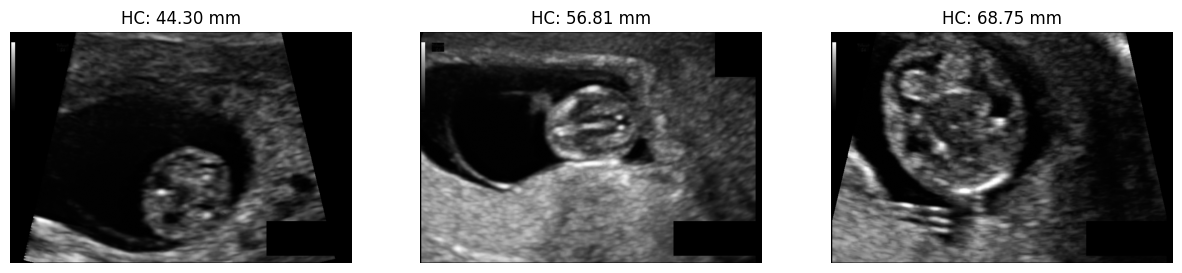

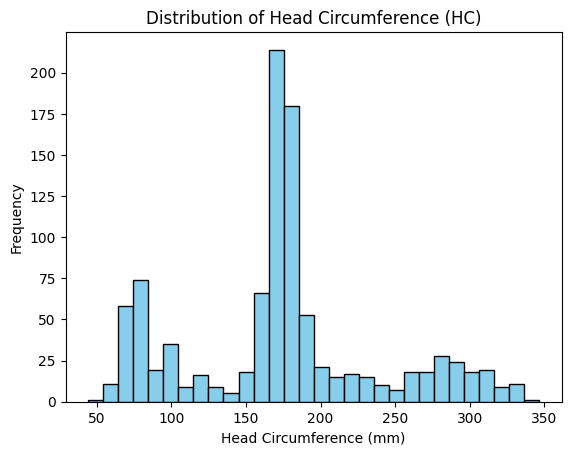

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

DATA_DIR = '/content/drive/MyDrive/test_set'
CSV_FILE = os.path.join(DATA_DIR, '/content/drive/MyDrive/training_set_pixel_size_and_HC.csv')
IMAGE_DIR = os.path.join(DATA_DIR, '/content/drive/MyDrive/training_set/training_set')

df = pd.read_csv(CSV_FILE)
print("Dataset shape:", df.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    img_name = df.iloc[i]['filename']
    hc_value = df.iloc[i]['head circumference (mm)']
    img_path = os.path.join(IMAGE_DIR, img_name)


    if not os.path.exists(img_path):
        print(f" LỖI: Không tìm thấy ảnh tại đường dẫn: {img_path}")
        print(" -> Vui lòng kiểm tra lại biến IMAGE_DIR!")
        break

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"HC: {hc_value:.2f} mm")
    axes[i].axis('off')

plt.show()
plt.hist(df['head circumference (mm)'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Head Circumference (HC)')
plt.xlabel('Head Circumference (mm)')
plt.ylabel('Frequency')
plt.show()

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# 1. Define the Custom PyTorch Dataset
class FetalHCDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        # Convert grayscale ultrasound to RGB as ResNet expects 3 channels
        image = Image.open(img_path).convert('RGB')
        hc_value = self.dataframe.iloc[idx]['head circumference (mm)']

        if self.transform:
            image = self.transform(image)

        # Return image and target as float32 for regression
        return image, torch.tensor(hc_value, dtype=torch.float32)

# 2. Image Preprocessing and Transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Split data into Training and Validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = FetalHCDataset(train_df, IMAGE_DIR, transform=transform)
val_dataset = FetalHCDataset(val_df, IMAGE_DIR, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [5]:
from torchvision import models

# 1. Initialize pretrained ResNet18
model = models.resnet18(pretrained=True)

# 2. Modify the final fully connected layer for Regression (1 output node)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

# 3. Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded and moved to: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Model loaded and moved to: cuda


In [6]:
import torch.optim as optim

# Define L1Loss (which is equivalent to Mean Absolute Error - MAE)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 15

print("Starting training process...")
for epoch in range(NUM_EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for images, targets in train_loader:
        images = images.to(device)
        # Reshape targets to match model output shape: (batch_size, 1)
        targets = targets.to(device).unsqueeze(1)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    epoch_train_mae = train_loss / len(train_loader.dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * images.size(0)

    epoch_val_mae = val_loss / len(val_loader.dataset)

    # Print metrics for the current epoch
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train MAE: {epoch_train_mae:.4f} mm | Val MAE: {epoch_val_mae:.4f} mm")

print("Training completed successfully!")

Starting training process...
Epoch [1/15] | Train MAE: 155.0371 mm | Val MAE: 137.2757 mm
Epoch [2/15] | Train MAE: 114.1681 mm | Val MAE: 81.9131 mm
Epoch [3/15] | Train MAE: 67.4488 mm | Val MAE: 33.8462 mm
Epoch [4/15] | Train MAE: 31.4269 mm | Val MAE: 25.4475 mm
Epoch [5/15] | Train MAE: 24.0500 mm | Val MAE: 25.7627 mm
Epoch [6/15] | Train MAE: 21.5188 mm | Val MAE: 19.4231 mm
Epoch [7/15] | Train MAE: 20.7208 mm | Val MAE: 33.8084 mm
Epoch [8/15] | Train MAE: 19.6877 mm | Val MAE: 27.0968 mm
Epoch [9/15] | Train MAE: 16.5729 mm | Val MAE: 15.7352 mm
Epoch [10/15] | Train MAE: 18.1278 mm | Val MAE: 16.7114 mm
Epoch [11/15] | Train MAE: 16.4797 mm | Val MAE: 19.2127 mm
Epoch [12/15] | Train MAE: 15.7668 mm | Val MAE: 17.8732 mm
Epoch [13/15] | Train MAE: 14.4887 mm | Val MAE: 19.8689 mm
Epoch [14/15] | Train MAE: 15.4765 mm | Val MAE: 16.6432 mm
Epoch [15/15] | Train MAE: 15.4010 mm | Val MAE: 14.5207 mm
Training completed successfully!


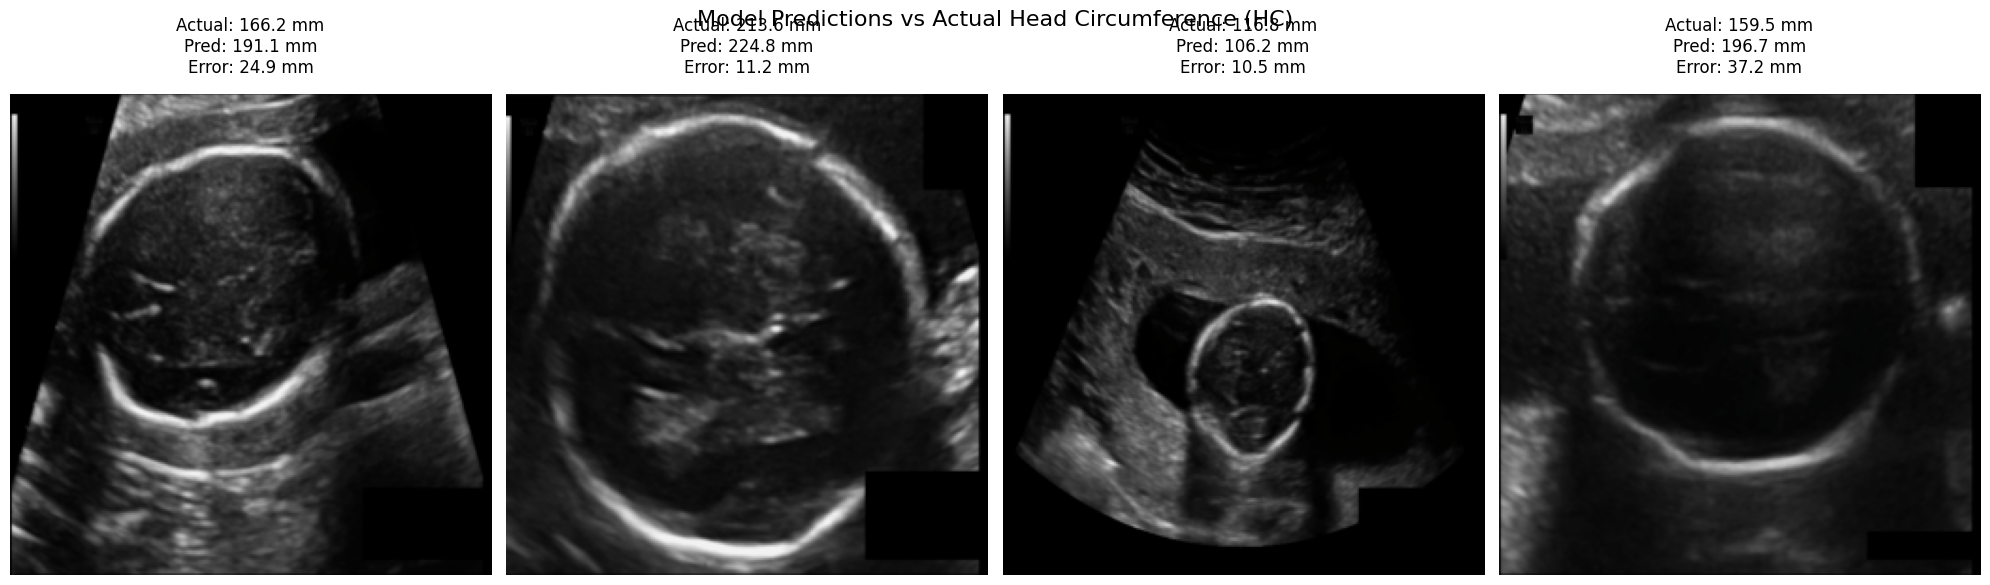

Model weights saved to 'fetal_hc_resnet18.pth'


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Put the model in evaluation mode
model.eval()

# Get one batch of validation data
dataiter = iter(val_loader)
images, targets = next(dataiter)

images_gpu = images.to(device)

# Make predictions
with torch.no_grad():
    predictions = model(images_gpu)

# Move predictions and targets back to CPU for visualization
predictions = predictions.cpu().numpy()
targets = targets.numpy()

# Plot 4 sample images with their actual and predicted HC values
fig, axes = plt.subplots(1, 4, figsize=(20, 6)) # Tăng chiều cao của figure

for i in range(4):
    # Un-normalize the image so it looks normal when plotted
    img = images[i].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # Display the image
    axes[i].imshow(img)

    # Calculate absolute error for this specific image
    abs_error = abs(targets[i] - predictions[i][0])

    # Set title with Actual, Predicted, and Error
    # Sử dụng tham số `pad` để đẩy text lên cao hơn, tránh đè vào ảnh
    axes[i].set_title(f"Actual: {targets[i]:.1f} mm\nPred: {predictions[i][0]:.1f} mm\nError: {abs_error:.1f} mm", pad=15)
    axes[i].axis('off')

# Sử dụng y parameter để điều chỉnh vị trí tiêu đề chính cao hơn
plt.suptitle("Model Predictions vs Actual Head Circumference (HC)", fontsize=16, y=1.0)
plt.tight_layout() # Thêm tight_layout để tự động tối ưu hóa khoảng cách
plt.show()

# Optional: Save the trained model weights
torch.save(model.state_dict(), "fetal_hc_resnet18.pth")
print("Model weights saved to 'fetal_hc_resnet18.pth'")